# Integrated Engineering Project
 # Two-Bar Spring Node Model

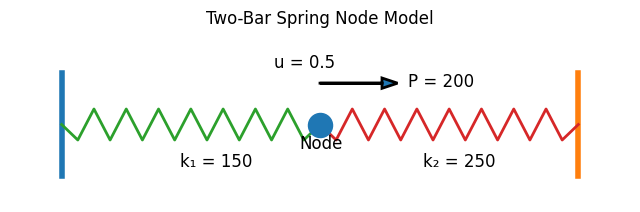

In [ ]:

# visual represtion of the two-bar spring node model
import matplotlib.pyplot as plt

# Given values
k1 = 150
k2 = 250
P = 200
u = P / (k1 + k2)

# Create figure
fig, ax = plt.subplots(figsize=(8, 3))

# Wall positions
left_wall = 0
right_wall = 10
node_x = 5
node_y = 0

# Draw walls
ax.plot([left_wall, left_wall], [-1, 1], linewidth=4)
ax.plot([right_wall, right_wall], [-1, 1], linewidth=4)

# Draw springs as zigzags
def draw_spring(x_start, x_end, y, coils=8, amplitude=0.3):
    xs = [x_start]
    ys = [y]
    length = x_end - x_start
    step = length / (coils * 2)

    for i in range(1, coils * 2):
        xs.append(x_start + i * step)
        ys.append(y + amplitude * (-1)**i)

    xs.append(x_end)
    ys.append(y)

    ax.plot(xs, ys, linewidth=2)

# Spring 1 and spring 2
draw_spring(left_wall, node_x, node_y)
draw_spring(node_x, right_wall, node_y)

# Draw node
ax.scatter(node_x, node_y, s=300, zorder=5)

# Draw external force P
ax.arrow(node_x, node_y + 0.8, 1.5, 0,
         head_width=0.2, head_length=0.3,
         linewidth=2, length_includes_head=True)

# Labels
ax.text(2.3, -0.8, f"k₁ = {k1}", fontsize=12)
ax.text(7.0, -0.8, f"k₂ = {k2}", fontsize=12)
ax.text(node_x + 1.7, node_y + 0.75, f"P = {P}", fontsize=12)
ax.text(node_x - 0.4, node_y - 0.45, "Node", fontsize=12)
ax.text(node_x - 0.9, node_y + 1.1, f"u = {u}", fontsize=12)

# Formatting
ax.set_xlim(-1, 11)
ax.set_ylim(-1.5, 1.8)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Two-Bar Spring Node Model")

plt.show()

# Question

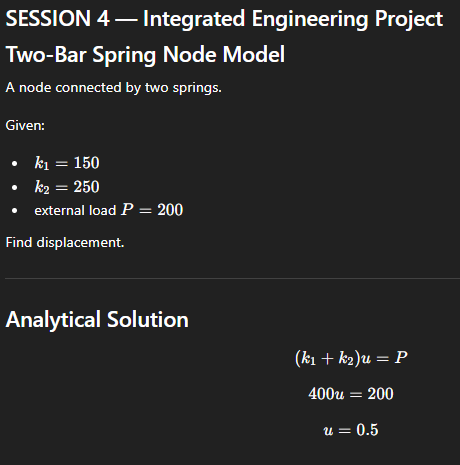

In [2]:
k1 = 150
k2 = 250
P = 200

u = P/(k1+k2)

print("Displacement =", u)

Displacement = 0.5


In [4]:
import numpy as np
A = np.array([[400]], dtype=float) # Matrix form version of the above equation, where 400 is the equivalent stiffness of the two springs in series.
b = np.array([200], dtype=float)

u = np.linalg.solve(A,b)
print(u)

[0.5]


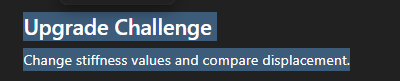

k1    k2    keq    displacement
150 250 400 0.5
200 300 500 0.4
300 500 800 0.25
100 150 250 0.8
500 500 1000 0.2


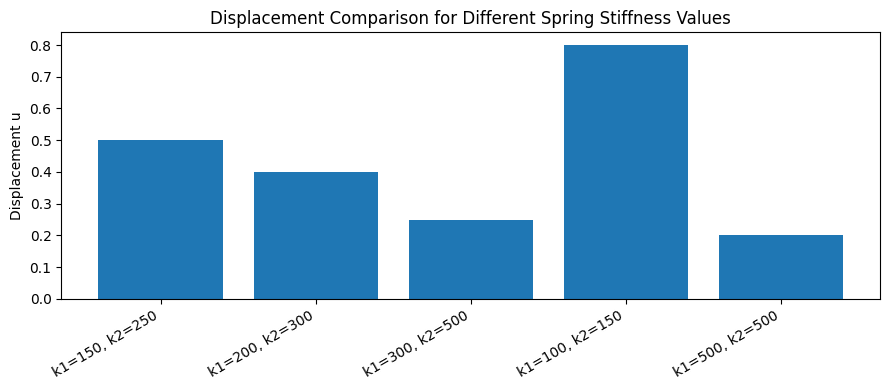

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# External load
P = 200

# Different stiffness cases: [k1, k2]
cases = np.array([
    [150, 250],
    [200, 300],
    [300, 500],
    [100, 150],
    [500, 500]
])

# Compute equivalent stiffness and displacement
keq = cases[:, 0] + cases[:, 1]
u = P / keq

# Print results
print("k1    k2    keq    displacement")
for i in range(len(cases)):
    print(cases[i,0], cases[i,1], keq[i], u[i])

# Plot comparison
labels = [f"k1={k1}, k2={k2}" for k1, k2 in cases]

plt.figure(figsize=(9, 4))
plt.bar(labels, u)
plt.ylabel("Displacement u")
plt.title("Displacement Comparison for Different Spring Stiffness Values")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()